开始执行 Lambda 搜索

>>> 正在测试 lambda_reg = 0.05 ...
>>> [1/3] 初始化协同定位物理场景...
>>> [2/3] 计算稠密全图基准 CRLB...
    原始稠密图边数: 107
    原始稠密图 CRLB: 311.5926

>>> [3/3] 开始 GNN 剪枝训练...
Epoch 000 | Total Loss: 7.2527 | CRLB: 360176.6875 (是基准的 1155.92 倍) | 保留边数: 4/107 | Tau: 0.997
Epoch 020 | Total Loss: 6.3396 | CRLB: 21617.6113 (是基准的 69.38 倍) | 保留边数: 42/107 | Tau: 0.941
Epoch 040 | Total Loss: 4.8150 | CRLB: 1490.2035 (是基准的 4.78 倍) | 保留边数: 65/107 | Tau: 0.889
Epoch 060 | Total Loss: 6.6945 | CRLB: 20663.9609 (是基准的 66.32 倍) | 保留边数: 50/107 | Tau: 0.839
Epoch 080 | Total Loss: 3.8683 | CRLB: 706.2596 (是基准的 2.27 倍) | 保留边数: 61/107 | Tau: 0.792
Epoch 100 | Total Loss: 5.2993 | CRLB: 805.1611 (是基准的 2.58 倍) | 保留边数: 87/107 | Tau: 0.748
Epoch 120 | Total Loss: 3.4736 | CRLB: 475.9459 (是基准的 1.53 倍) | 保留边数: 61/107 | Tau: 0.706
Epoch 140 | Total Loss: 4.2702 | CRLB: 351.3854 (是基准的 1.13 倍) | 保留边数: 83/107 | Tau: 0.666
Epoch 160 | Total Loss: 3.7840 | CRLB: 435.1658 (是基准的 1.40 倍) | 保留边数: 69/107 | Tau: 0.629
Epoch 180 |

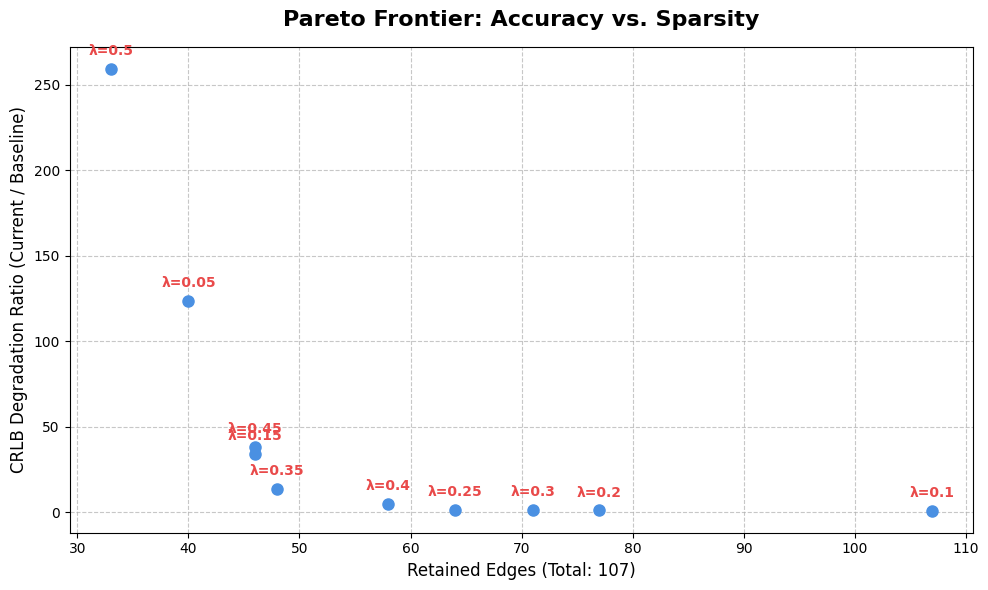


搜索结果汇总表
Lambda (λ)   | 保留边数 / 总边数         | CRLB 倍率     
-----------------------------------------------------------
0.05         | 40 / 107              | 123.7796    
0.1          | 107 / 107             | 1.0000      
0.15         | 46 / 107              | 34.2273     
0.2          | 77 / 107              | 1.1218      
0.25         | 64 / 107              | 1.3882      
0.3          | 71 / 107              | 1.3450      
0.35         | 48 / 107              | 13.4708     
0.4          | 58 / 107              | 5.0522      
0.45         | 46 / 107              | 38.0234     
0.5          | 33 / 107              | 259.2815    


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from GNN_learning.train import train_gnn_sparsifier

TORCH_SEED = 1
EPOCHS = 1000

def search_best_lambda():
    # 1. 定义要探索的 lambda 候选列表
    lambda_candidates = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
    # lambda_candidates = [0.28, 0.29, 0.31, 0.32]
    
    results_edges = []
    results_crlb_ratio = []
    
    print("==================================================")
    print("开始执行 Lambda 搜索")
    print("==================================================")
    
    # 2. 遍历每一个 lambda 进行完整训练
    for lam in lambda_candidates:
        print(f"\n>>> 正在测试 lambda_reg = {lam} ...")
        torch.manual_seed(TORCH_SEED)
        _, _, data, final_edges, crlb_final, crlb_full = train_gnn_sparsifier(
            epochs=EPOCHS, lr=0.01, lambda_reg=lam
        )
        
        crlb_ratio = crlb_final / crlb_full
        results_edges.append(final_edges)
        results_crlb_ratio.append(crlb_ratio)
        
        print(f"[测试完成] Lambda: {lam} | 保留边数: {final_edges} | CRLB 倍数: {crlb_ratio:.2f}")

    # 3. 绘制曲线
    print("\n>>> 所有测试完成，正在绘制曲线...")
    plt.figure(figsize=(10, 6))
    
    # 画出散点和连线
    plt.plot(results_edges, results_crlb_ratio, marker='o', linestyle='', color='#4A90E2', linewidth=2, markersize=8)
    
    # 标注每个点对应的 lambda 值
    for i, lam in enumerate(lambda_candidates):
        plt.annotate(
            f'λ={lam}', 
            (results_edges[i], results_crlb_ratio[i]),
            textcoords="offset points", 
            xytext=(0,10), 
            ha='center',
            fontsize=10,
            fontweight='bold',
            color='#E94A4A'
        )

    # 设置图表格式
    E_total = data['edge_index'].shape[1]
    plt.title('Pareto Frontier: Accuracy vs. Sparsity', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(f'Retained Edges (Total: {E_total})', fontsize=12)
    plt.ylabel('CRLB Degradation Ratio (Current / Baseline)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

    # 4. 输出结果汇总表
    print("\n===========================================================")
    print("搜索结果汇总表")
    print("===========================================================")
    # 打印表头，确保对齐
    print(f"{'Lambda (λ)':<12} | {'保留边数 / 总边数':<18} | {'CRLB 倍率':<12}")
    print("-" * 59)
    
    # 遍历输出每一行数据
    for i, lam in enumerate(lambda_candidates):
        edge_str = f"{results_edges[i]} / {E_total}"
        crlb_str = f"{results_crlb_ratio[i]:.4f}"
        print(f"{lam:<12} | {edge_str:<21} | {crlb_str:<12}")
    print("===========================================================")

if __name__ == "__main__":
    search_best_lambda()

# seed | lambda_reg
#  1   |   0.2
#  2   |   0.04
#  3   |   0.25
#  4   |   0.1
#  5   |   1.1
#  6   |   0.3